<a href="https://colab.research.google.com/github/OfirW3/IIoT-Network-Intrusion-Detection-Technion-ML-Course-Final-Project/blob/main/IDS_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## === NIDS (Netork Instrusion Detection System) Project by Ofir Weit ===

##Config, Imports and Leakage Filter

In [ ]:
# ==========================================
# MASTER SETUP (Imports, Config & Seeds)
# ==========================================
import os
import re
import gc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn (Preprocessing & Metrics)
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score

# XGBoost
import xgboost as xgb

# Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# TabNet (PyTorch)
import torch
from pytorch_tabnet.tab_model import TabNetClassifier

# --- 4. CONFIGURATION ---
DATA_PATH = "/content/drive/MyDrive/CIC_IIOT_2025/cic_iiot_2025_combined_clean_sampled.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Model Specific Configs
N_ESTIMATORS = 100        # For RF/XGB
BATCH_SIZE = 1024         # For TabNet/NN
MAX_EPOCHS = 100           # For TabNet
LATENT_DIM = 32           # For Autoencoder
CONTAMINATION = 0.05      # For Isolation Forest

# --- 5. REPRODUCIBILITY SETUP ---
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seeds(RANDOM_STATE)

# --- 6. HELPER FUNCTIONS ---
def now():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# --- 7. STATUS CHECK ---
print(f"[{now()}] === MASTER SETUP COMPLETE ===")
print(f"   -> Python: {sys.version.split()[0]}")
print(f"   -> TensorFlow: {tf.__version__}")
print(f"   -> PyTorch: {torch.__version__} | Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")
print(f"   -> Data Path: {DATA_PATH}")

[2026-02-17 16:18:32] === MASTER SETUP COMPLETE ===
   -> Python: 3.12.12
   -> TensorFlow: 2.19.0
   -> PyTorch: 2.9.0+cu128 | Device: GPU
   -> Data Path: /content/drive/MyDrive/CIC_IIOT_2025/cic_iiot_2025_combined_clean_sampled.csv


In [ ]:
# ==========================================
# BLOCK 2: UNIVERSAL DATA PREP
# ==========================================
print(f"[{now()}] Preparing Universal Datasets...")

# 1. Clean & Separate Targets
if 'df' not in locals(): raise ValueError("Run Block 2 first.")

drop_cols = [c for c in ["label1", "label2", "target_bin", "target_multi"] if c in df.columns]
X_raw = df.drop(columns=drop_cols).apply(pd.to_numeric, errors='coerce').fillna(0)

# Targets
y_bin = (df["label1"].astype(str).str.lower() != "benign").astype(int).values
le_multi = LabelEncoder()
y_multi = le_multi.fit_transform(df["label2"].astype(str).fillna("Unknown"))

# 2. Split (Stratified on Binary Target)
X_train_raw, X_test_raw, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X_raw.values, y_bin, y_multi, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_bin
)

# 3. Scale (For Neural Nets & XGB)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"[{now()}] Data Ready.")
print(f"   -> Raw Shapes: {X_train_raw.shape}")
print(f"   -> Scaled Shapes: {X_train_scaled.shape}")

[2026-02-17 16:18:32] Preparing Universal Datasets...
[2026-02-17 16:18:32] Data Ready.
   -> Raw Shapes: (31842, 60)
   -> Scaled Shapes: (31842, 60)


In [ ]:
# ==========================================
# BLOCK 3: MASTER LEAKAGE FILTER
# ==========================================
import pandas as pd
import numpy as np

print(f"[{now()}] Reading CSV...")
df = pd.read_csv(DATA_PATH, low_memory=False, on_bad_lines="skip")

# --- 1. DEFINE FILTER LISTS ---

# FATAL: Immediate Drop (unless specifically exempted like 'width' for 'id')
FATAL_KEYWORDS = [
    "mac",           # Bans: 'network_macs_dst_count', 'src_mac'
    "port",          # Bans: 'network_ports_src', 'dst_port'
    "addr",          # Bans: 'ip_address', 'email_addr'
    "id",            # Bans: 'flow_id', 'device_id' (Exempts: 'width', 'valid')
    "uuid", "token", "serial", "socket", "session",
    "ip_src", "ip_dst", "src_ip", "dst_ip" # Explicit IP bans
]

# TOXIC: Drop UNLESS a "Safe" keyword is also present
TOXIC_KEYWORDS = [
    "time", "date", "timestamp",             # Schedule leaks
    "ttl", "window", "mss", "seq", "ack"     # OS Fingerprinting leaks
]

# SAFE: These words can save a Toxic feature (e.g., 'flow_duration' saves 'flow')
SAFE_KEYWORDS = ["duration", "interval", "rate", "delta", "mean", "std", "avg"]

# --- 2. EXECUTE FILTERING ---
feature_cols = []
dropped_examples = []
kept_examples = []

print(f"[{now()}] Filtering features...")

for c in df.columns:
    c_lower = c.lower().strip()

    # A. Always Skip Labels
    if "label" in c_lower:
        continue

    # B. FATAL CHECK
    is_fatal = False
    for fatal in FATAL_KEYWORDS:
        if fatal in c_lower:
            # Exception Logic for 'id'
            if fatal == "id":
                # If 'id' is present, check if it's actually 'width' or 'valid' (safe words containing id concept)
                if "width" in c_lower or "valid" in c_lower:
                    continue # This 'id' match is safe, check next keyword

            # If we get here, it is a fatal match
            is_fatal = True
            break

    if is_fatal:
        dropped_examples.append(c)
        continue

    # C. TOXIC CHECK (Conditional)
    is_toxic = False
    for toxic in TOXIC_KEYWORDS:
        if toxic in c_lower:
            is_toxic = True
            break

    # D. SAVIOUR CHECK
    if is_toxic:
        is_safe = False
        for safe in SAFE_KEYWORDS:
            if safe in c_lower:
                is_safe = True
                break

        # If Toxic AND Not Safe -> DROP
        if not is_safe:
            dropped_examples.append(c)
            continue

    # E. KEEP
    feature_cols.append(c)
    kept_examples.append(c)

# --- 3. APPLY TO DATAFRAME ---
# Update df to keep only selected features + labels
cols_to_keep = feature_cols + ["label1", "label2"]
# Ensure labels actually exist before selecting
cols_to_keep = [c for c in cols_to_keep if c in df.columns]

df = df[cols_to_keep]

# --- 4. REPORTING ---
print(f"[{now()}] Filtering Complete.")
print(f"   -> Original Columns: {len(dropped_examples) + len(feature_cols) + 2}")
print(f"   -> Features Kept:    {len(feature_cols)}")
print(f"   -> Features Dropped: {len(dropped_examples)}")
print(f"   -> Shape of Clean DF:{df.shape}")

print("\n[Examples of DROPPED Columns]:")
print(f"   {dropped_examples[:5]}")

print("\n[Examples of KEPT Columns]:")
print(f"   {kept_examples[:5]}")

[2026-02-17 16:18:32] Reading CSV...
[2026-02-17 16:18:35] Filtering features...
[2026-02-17 16:18:35] Filtering Complete.
   -> Original Columns: 91
   -> Features Kept:    60
   -> Features Dropped: 29
   -> Shape of Clean DF:(39803, 62)

[Examples of DROPPED Columns]:
   ['device_mac', 'network_fragmented-packets', 'network_macs_all', 'network_macs_all_count', 'network_macs_dst']

[Examples of KEPT Columns]:
   ['device_name', 'log_data-ranges_avg', 'log_data-ranges_max', 'log_data-ranges_min', 'log_data-ranges_std_deviation']


##First Random Forest

In [ ]:
# ==========================================
# BLOCK 3.1: TRAIN RANDOM FOREST (BINARY)
# ==========================================
print(f"[{now()}] Training Binary Random Forest...")
if 'X_train_raw' not in locals(): raise ValueError("Run Block 2.5 first.")

rf_bin = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
rf_bin.fit(X_train_raw, y_train_bin)

print(f"[{now()}] Binary RF Saved as 'rf_bin'.")

[2026-02-17 16:18:35] Training Binary Random Forest...
[2026-02-17 16:18:40] Binary RF Saved as 'rf_bin'.


[2026-02-17 16:18:40] Evaluating Binary RF...

--- RF Binary Report ---
              precision    recall  f1-score   support

      Benign       0.82      0.97      0.89      2736
      Attack       0.98      0.89      0.93      5225

    accuracy                           0.92      7961
   macro avg       0.90      0.93      0.91      7961
weighted avg       0.93      0.92      0.92      7961



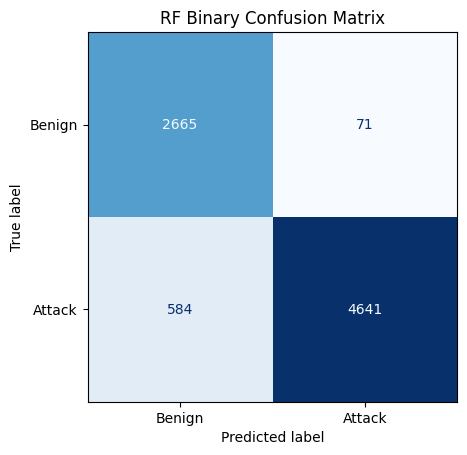

In [ ]:
# ==========================================
# BLOCK 3.2: EVALUATE RANDOM FOREST (BINARY)
# ==========================================
print(f"[{now()}] Evaluating Binary RF...")

preds = rf_bin.predict(X_test_raw)
print("\n--- RF Binary Report ---")
print(classification_report(y_test_bin, preds, target_names=["Benign", "Attack"]))

ConfusionMatrixDisplay.from_predictions(y_test_bin, preds, display_labels=["Benign", "Attack"], cmap="Blues", colorbar=False)
plt.title("RF Binary Confusion Matrix")
plt.show()

In [ ]:
# ==========================================
# BLOCK 3.3: TRAIN RANDOM FOREST (MULTI)
# ==========================================
print(f"[{now()}] Training Multi-Class Random Forest...")

rf_multi = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
rf_multi.fit(X_train_raw, y_train_multi)

print(f"[{now()}] Multi-Class RF Saved as 'rf_multi'.")

[2026-02-17 16:18:40] Training Multi-Class Random Forest...
[2026-02-17 16:18:44] Multi-Class RF Saved as 'rf_multi'.


[2026-02-17 16:18:44] Evaluating Multi-Class RF...

--- RF Multi-Class Report ---
              precision    recall  f1-score   support

      benign       0.82      0.98      0.89      2736
       brute       0.95      0.69      0.80       192
        ddos       0.98      0.92      0.95      2171
     malware       0.93      0.90      0.91       758
        mitm       0.94      0.90      0.92       770
       recon       0.96      0.74      0.84      1051
         web       0.98      0.84      0.90       283

    accuracy                           0.90      7961
   macro avg       0.94      0.85      0.89      7961
weighted avg       0.91      0.90      0.90      7961



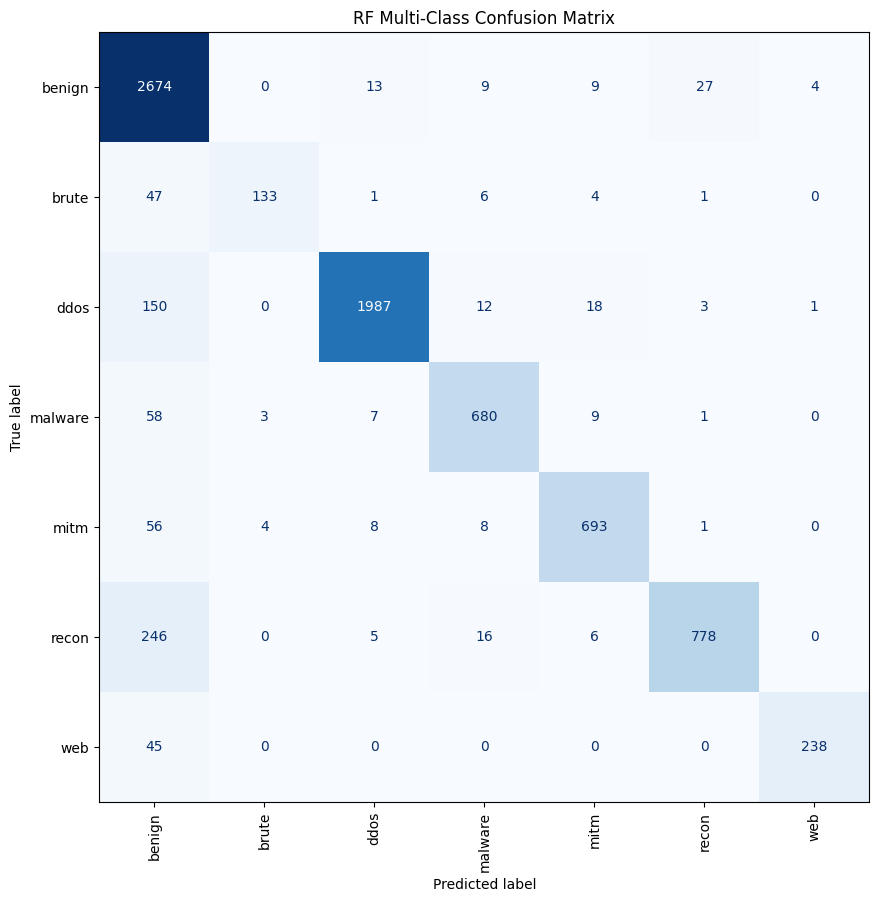

In [ ]:
# ==========================================
# BLOCK 3.4: EVALUATE RANDOM FOREST (MULTI)
# ==========================================
print(f"[{now()}] Evaluating Multi-Class RF...")

preds = rf_multi.predict(X_test_raw)
unique_labels = sorted(set(y_test_multi) | set(preds))
target_names = [le_multi.classes_[i] for i in unique_labels]

print("\n--- RF Multi-Class Report ---")
print(classification_report(y_test_multi, preds, target_names=target_names))

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_test_multi, preds, display_labels=target_names, xticks_rotation="vertical", cmap="Blues", colorbar=False, ax=ax)
plt.title("RF Multi-Class Confusion Matrix")
plt.show()

##Neural Network for classifying label1 and label2

In [ ]:
# ==========================================
# BLOCK 4.1: TRAIN TABNET (BINARY)
# ==========================================
print(f"[{now()}] Training Binary TabNet...")

tabnet_bin = TabNetClassifier(optimizer_fn=torch.optim.Adam, verbose=1)
tabnet_bin.fit(
    X_train_raw, y_train_bin,
    eval_set=[(X_test_raw, y_test_bin)],
    max_epochs=20, batch_size=BATCH_SIZE, patience=5
)
print(f"[{now()}] Binary TabNet Saved as 'tabnet_bin'.")

[2026-02-17 16:18:45] Training Binary TabNet...


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.44565 | val_0_auc: 0.83571 |  0:00:01s
epoch 1  | loss: 0.33813 | val_0_auc: 0.88979 |  0:00:02s
epoch 2  | loss: 0.32457 | val_0_auc: 0.91035 |  0:00:04s
epoch 3  | loss: 0.3148  | val_0_auc: 0.91422 |  0:00:06s
epoch 4  | loss: 0.30626 | val_0_auc: 0.91657 |  0:00:08s
epoch 5  | loss: 0.30543 | val_0_auc: 0.91781 |  0:00:09s
epoch 6  | loss: 0.3053  | val_0_auc: 0.91819 |  0:00:11s
epoch 7  | loss: 0.2984  | val_0_auc: 0.92009 |  0:00:12s
epoch 8  | loss: 0.29383 | val_0_auc: 0.91449 |  0:00:14s
epoch 9  | loss: 0.3024  | val_0_auc: 0.91544 |  0:00:15s
epoch 10 | loss: 0.29844 | val_0_auc: 0.91564 |  0:00:17s
epoch 11 | loss: 0.29354 | val_0_auc: 0.9151  |  0:00:18s
epoch 12 | loss: 0.29047 | val_0_auc: 0.91486 |  0:00:20s

Early stopping occurred at epoch 12 with best_epoch = 7 and best_val_0_auc = 0.92009


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


[2026-02-17 16:19:06] Binary TabNet Saved as 'tabnet_bin'.


[2026-02-17 16:19:06] Evaluating Binary TabNet...

--- TabNet Binary Report ---
              precision    recall  f1-score   support

      Benign       0.75      0.94      0.83      2736
      Attack       0.97      0.83      0.89      5225

    accuracy                           0.87      7961
   macro avg       0.86      0.89      0.86      7961
weighted avg       0.89      0.87      0.87      7961



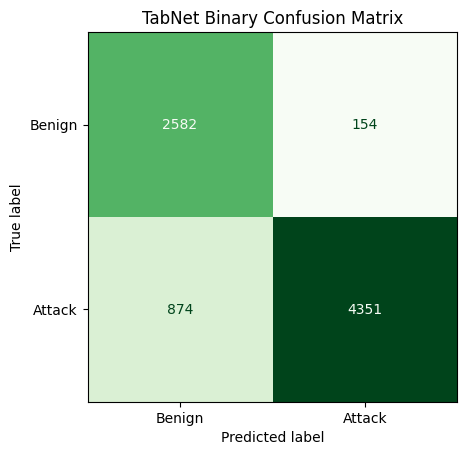

In [ ]:
# ==========================================
# BLOCK 4.2: EVALUATE TABNET (BINARY)
# ==========================================
print(f"[{now()}] Evaluating Binary TabNet...")

preds = tabnet_bin.predict(X_test_raw)
print("\n--- TabNet Binary Report ---")
print(classification_report(y_test_bin, preds, target_names=["Benign", "Attack"]))

ConfusionMatrixDisplay.from_predictions(y_test_bin, preds, display_labels=["Benign", "Attack"], cmap="Greens", colorbar=False)
plt.title("TabNet Binary Confusion Matrix")
plt.show()

In [ ]:
# ==========================================
# BLOCK 4.3: TRAIN TABNET (MULTI)
# ==========================================
print(f"[{now()}] Training Multi-Class TabNet...")

tabnet_multi = TabNetClassifier(optimizer_fn=torch.optim.Adam, verbose=1)
tabnet_multi.fit(
    X_train_raw, y_train_multi,
    eval_set=[(X_test_raw, y_test_multi)],
    max_epochs=20, batch_size=BATCH_SIZE, patience=5
)
print(f"[{now()}] Multi-Class TabNet Saved as 'tabnet_multi'.")

[2026-02-17 16:19:07] Training Multi-Class TabNet...


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.44933 | val_0_accuracy: 0.3796  |  0:00:01s
epoch 1  | loss: 0.93485 | val_0_accuracy: 0.6366  |  0:00:02s
epoch 2  | loss: 0.79816 | val_0_accuracy: 0.66964 |  0:00:04s
epoch 3  | loss: 0.73485 | val_0_accuracy: 0.69866 |  0:00:05s
epoch 4  | loss: 0.70222 | val_0_accuracy: 0.70695 |  0:00:07s
epoch 5  | loss: 0.677   | val_0_accuracy: 0.73596 |  0:00:08s
epoch 6  | loss: 0.65593 | val_0_accuracy: 0.7229  |  0:00:10s
epoch 7  | loss: 0.64318 | val_0_accuracy: 0.81397 |  0:00:12s
epoch 8  | loss: 0.6311  | val_0_accuracy: 0.79261 |  0:00:13s
epoch 9  | loss: 0.60852 | val_0_accuracy: 0.74915 |  0:00:15s
epoch 10 | loss: 0.6108  | val_0_accuracy: 0.75832 |  0:00:16s
epoch 11 | loss: 0.61028 | val_0_accuracy: 0.7548  |  0:00:18s
epoch 12 | loss: 0.61195 | val_0_accuracy: 0.79927 |  0:00:19s

Early stopping occurred at epoch 12 with best_epoch = 7 and best_val_0_accuracy = 0.81397


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


[2026-02-17 16:19:27] Multi-Class TabNet Saved as 'tabnet_multi'.


[2026-02-17 16:19:27] Evaluating Multi-Class TabNet...

--- TabNet Multi-Class Report ---
              precision    recall  f1-score   support

      benign       0.72      0.97      0.83      2736
       brute       0.58      0.17      0.27       192
        ddos       0.97      0.86      0.91      2171
     malware       0.75      0.72      0.74       758
        mitm       0.77      0.65      0.70       770
       recon       0.98      0.64      0.77      1051
         web       0.85      0.77      0.81       283

    accuracy                           0.81      7961
   macro avg       0.80      0.68      0.72      7961
weighted avg       0.83      0.81      0.81      7961



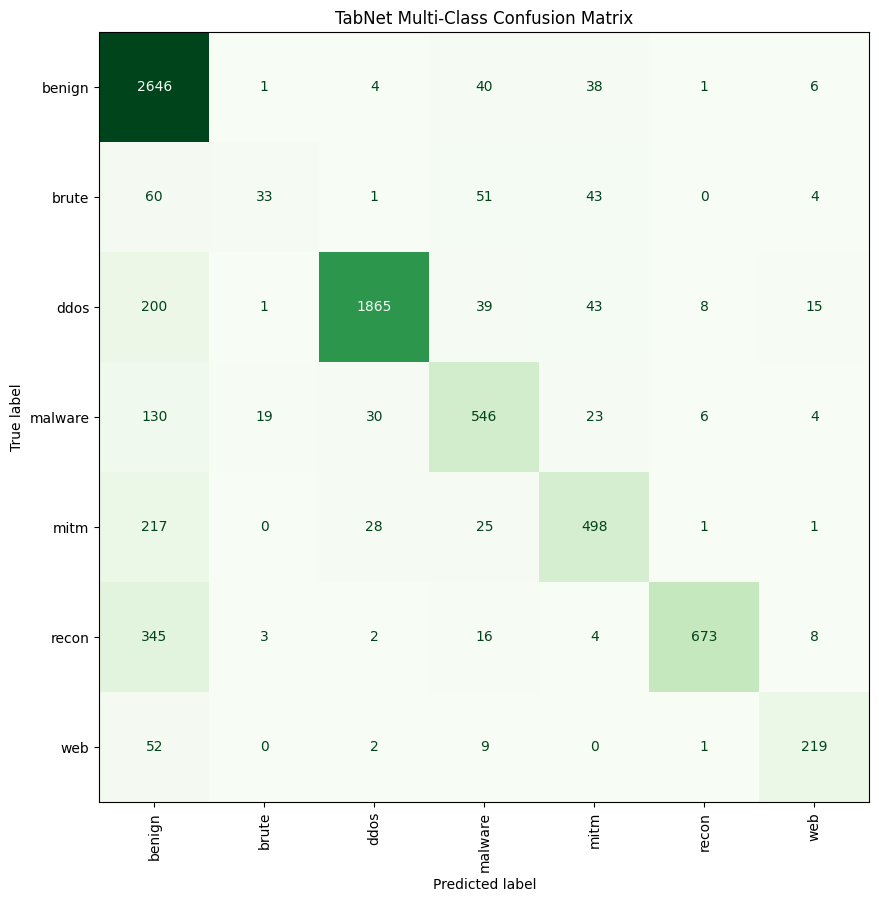

In [ ]:
# ==========================================
# BLOCK 4.4: EVALUATE TABNET (MULTI)
# ==========================================
print(f"[{now()}] Evaluating Multi-Class TabNet...")

preds = tabnet_multi.predict(X_test_raw)
unique_labels = sorted(set(y_test_multi) | set(preds))
target_names = [le_multi.classes_[i] for i in unique_labels]

print("\n--- TabNet Multi-Class Report ---")
print(classification_report(y_test_multi, preds, target_names=target_names))

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_test_multi, preds, display_labels=target_names, xticks_rotation="vertical", cmap="Greens", colorbar=False, ax=ax)
plt.title("TabNet Multi-Class Confusion Matrix")
plt.show()

##FFNN and XGBoost combination


In [ ]:
# ==========================================
# BLOCK 5.1: TRAIN AUTOENCODER (SHARED)
# ==========================================
print(f"[{now()}] Training Autoencoder...")

# Define & Train
input_dim = X_train_scaled.shape[1]
input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(32, activation='relu')(input_layer)
decoded = layers.Dense(input_dim, activation='linear')(encoded)

autoencoder = models.Model(inputs=input_layer, outputs=decoded)
encoder = models.Model(inputs=input_layer, outputs=encoded)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_train_scaled, X_train_scaled, epochs=20, batch_size=1024, verbose=0)

# Generate Features
global_encoder = encoder
X_train_enc = global_encoder.predict(X_train_scaled, verbose=0)
X_test_enc = global_encoder.predict(X_test_scaled, verbose=0)

print(f"[{now()}] Encoder Trained. Features Generated.")

[2026-02-17 16:19:27] Training Autoencoder...
[2026-02-17 16:19:37] Encoder Trained. Features Generated.


In [ ]:
# ==========================================
# BLOCK 5.2: TRAIN HYBRID XGBOOST (BINARY)
# ==========================================
print(f"[{now()}] Training Binary XGBoost...")

xgb_bin = xgb.XGBClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
xgb_bin.fit(X_train_enc, y_train_bin)

print(f"[{now()}] Binary XGB Saved as 'xgb_bin'.")

[2026-02-17 16:19:37] Training Binary XGBoost...
[2026-02-17 16:19:38] Binary XGB Saved as 'xgb_bin'.


In [ ]:
# ==========================================
# BLOCK 5.2: TRAIN HYBRID XGBOOST (BINARY)
# ==========================================
print(f"[{now()}] Training Binary XGBoost...")

xgb_bin = xgb.XGBClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
xgb_bin.fit(X_train_enc, y_train_bin)

print(f"[{now()}] Binary XGB Saved as 'xgb_bin'.")

[2026-02-17 16:19:38] Training Binary XGBoost...
[2026-02-17 16:19:39] Binary XGB Saved as 'xgb_bin'.


In [ ]:
# ==========================================
# BLOCK 5.4: TRAIN HYBRID XGBOOST (MULTI)
# ==========================================
print(f"[{now()}] Training Multi-Class XGBoost...")

xgb_multi = xgb.XGBClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
xgb_multi.fit(X_train_enc, y_train_multi)

print(f"[{now()}] Multi-Class XGB Saved as 'xgb_multi'.")

[2026-02-17 16:19:39] Training Multi-Class XGBoost...
[2026-02-17 16:19:46] Multi-Class XGB Saved as 'xgb_multi'.


[2026-02-17 16:19:46] Evaluating Multi-Class XGBoost...

--- Hybrid Multi-Class Report ---
              precision    recall  f1-score   support

      benign       0.77      0.96      0.85      2736
       brute       0.65      0.38      0.48       192
        ddos       0.98      0.89      0.93      2171
     malware       0.90      0.80      0.85       758
        mitm       0.79      0.79      0.79       770
       recon       0.97      0.69      0.80      1051
         web       0.96      0.82      0.88       283

    accuracy                           0.86      7961
   macro avg       0.86      0.76      0.80      7961
weighted avg       0.87      0.86      0.85      7961



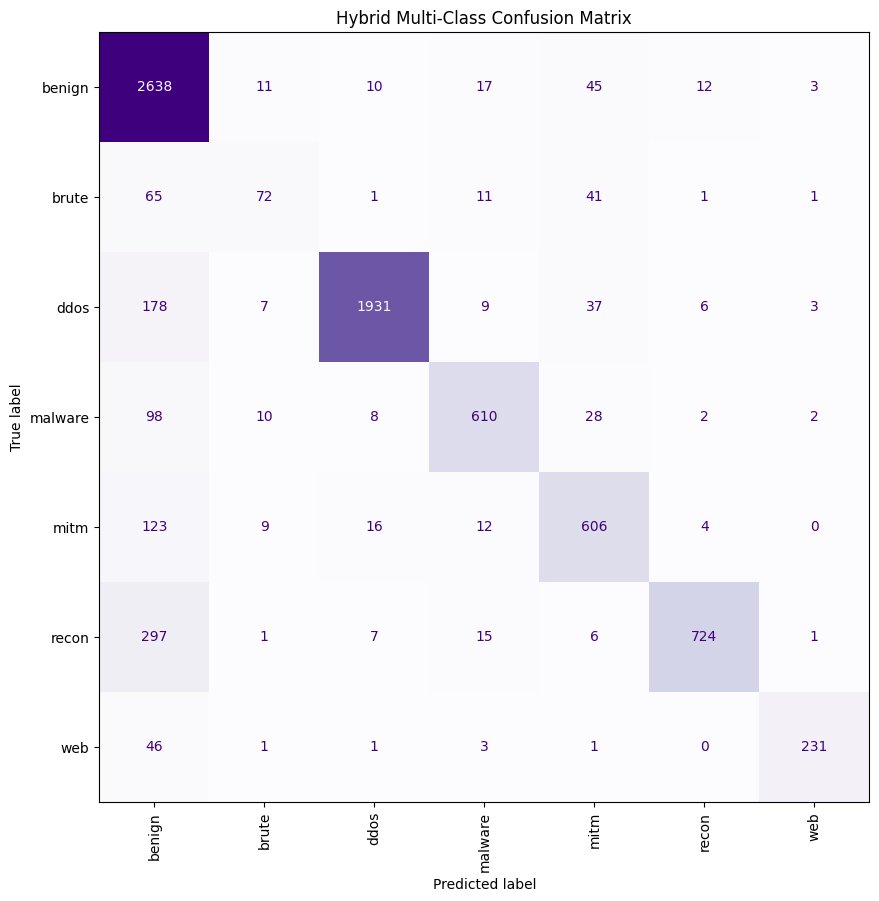

In [ ]:
# ==========================================
# BLOCK 5.5: EVALUATE HYBRID XGBOOST (MULTI)
# ==========================================
print(f"[{now()}] Evaluating Multi-Class XGBoost...")

preds = xgb_multi.predict(X_test_enc)
unique_labels = sorted(set(y_test_multi) | set(preds))
target_names = [le_multi.classes_[i] for i in unique_labels]

print("\n--- Hybrid Multi-Class Report ---")
print(classification_report(y_test_multi, preds, target_names=target_names))

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_test_multi, preds, display_labels=target_names, xticks_rotation="vertical", cmap="Purples", colorbar=False, ax=ax)
plt.title("Hybrid Multi-Class Confusion Matrix")
plt.show()

##Anomaly detection using Sepration Forest

In [ ]:
# ==========================================
# BLOCK 6.1: TRAIN ISOLATION FOREST
# ==========================================
print(f"[{now()}] Training Isolation Forest (Anomaly Detection)...")

if 'X_train_scaled' not in locals(): raise ValueError("Run Block 2.5 first.")

# 1. Filter Train Set -> Keep ONLY Benign (Class 0)
# We use the scaled data from Block 2.5
X_train_benign = X_train_scaled[y_train_bin == 0]

print(f"   -> Training on {len(X_train_benign)} Benign samples only.")

# 2. Train Model
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.01, # Estimated % of outliers in clean data
    max_features=1.0,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

iso_forest.fit(X_train_benign)

print(f"[{now()}] Isolation Forest Saved as 'iso_forest'.")

[2026-02-17 16:23:41] Training Isolation Forest (Anomaly Detection)...
   -> Training on 10944 Benign samples only.
[2026-02-17 16:23:41] Isolation Forest Saved as 'iso_forest'.


[2026-02-17 16:23:41] Evaluating Anomaly Detection...

--- Isolation Forest Report ---
                  precision    recall  f1-score   support

 Benign (Normal)       0.34      0.87      0.49      2729
Attack (Anomaly)       0.65      0.12      0.21      5232

        accuracy                           0.38      7961
       macro avg       0.50      0.50      0.35      7961
    weighted avg       0.55      0.38      0.31      7961



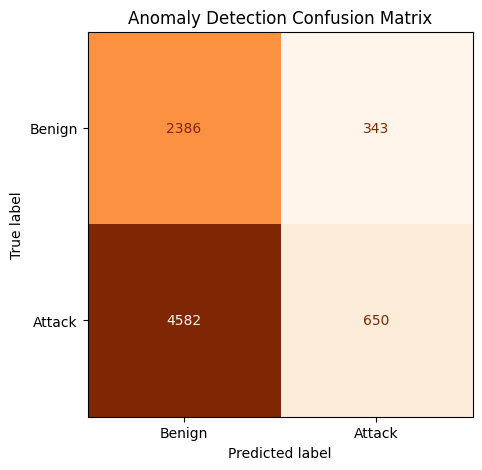

[2026-02-17 16:23:42] Stats:
   -> Total Test Samples: 7961
   -> Detected Anomalies: 993


In [ ]:
# ==========================================
# BLOCK 6.2: EVALUATE ISOLATION FOREST
# ==========================================
print(f"[{now()}] Evaluating Anomaly Detection...")

# 1. Predict (Returns: 1 = Normal, -1 = Anomaly)
preds_raw = iso_forest.predict(X_test_scaled)

# 2. Convert to Binary (0 = Benign, 1 = Attack)
# Map:  1 -> 0 (Benign)
#      -1 -> 1 (Attack)
preds_iso = np.where(preds_raw == 1, 0, 1)

# 3. Evaluation Report
print("\n--- Isolation Forest Report ---")
print(classification_report(y_test_bin, preds_iso, target_names=["Benign (Normal)", "Attack (Anomaly)"]))

# 4. Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_bin,
    preds_iso,
    display_labels=["Benign", "Attack"],
    cmap="Oranges",
    colorbar=False,
    ax=ax
)
plt.title("Anomaly Detection Confusion Matrix")
plt.show()

# 5. Sanity Check
print(f"[{now()}] Stats:")
print(f"   -> Total Test Samples: {len(y_test_bin)}")
print(f"   -> Detected Anomalies: {sum(preds_iso)}")

##Models's performance comparison

[2026-02-17 16:31:41] Starting Honest Final Comparison...
[2026-02-17 16:31:41] Gathering Binary Results...
[2026-02-17 16:31:42] Gathering Multi-Class Results...

--- BINARY PERFORMANCE (Benign vs Attack) ---
                  Accuracy  Honest F1 (Macro)
Model                                        
Random Forest     0.538500           0.630531
TabNet            0.532345           0.617644
Hybrid XGBoost    0.536616           0.625976
Isolation Forest  0.381359           0.208835

--- MULTI-CLASS PERFORMANCE (Attack Types - Macro Avg) ---
                Accuracy  Honest F1 (Macro)
Model                                      
Random Forest   0.246577           0.143154
TabNet          0.257254           0.144305
Hybrid XGBoost  0.253486           0.147400


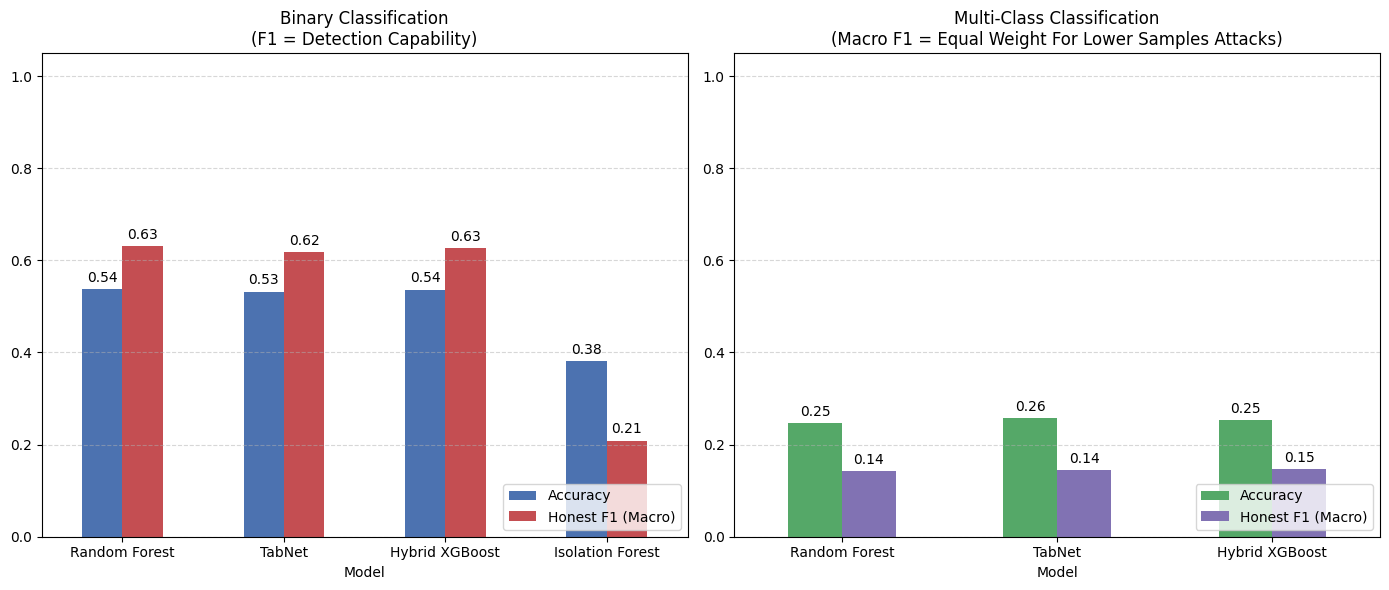

In [ ]:
# ==========================================
# BLOCK 7: HONEST MODEL COMPARISON
# ==========================================
print(f"[{now()}] Starting Honest Final Comparison...")

results_bin = []
results_multi = []

# --- 1. HONEST SCORING FUNCTION ---
def evaluate_model(name, y_true, y_pred, task="binary"):
    # Accuracy: Overall correctness
    acc = accuracy_score(y_true, y_pred)

    # F1-Score Selection:
    if task == "binary":
        # For Binary: Standard F1 (Balance of Precision/Recall for Attack class)
        f1 = f1_score(y_true, y_pred, pos_label=1)
    else:
        # For Multi-Class: MACRO F1
        # This is the "Honest" metric. It treats small attacks (Brute Force)
        # as equally important to large ones (DDoS).
        f1 = f1_score(y_true, y_pred, average='macro')

    return {"Model": name, "Accuracy": acc, "Honest F1 (Macro)": f1}

# --- 2. GATHER BINARY RESULTS (Label 1) ---
print(f"[{now()}] Gathering Binary Results...")

# Random Forest
if 'rf_bin' in locals():
    preds = rf_bin.predict(X_test_raw)
    results_bin.append(evaluate_model("Random Forest", y_test_bin, preds, task="binary"))

# TabNet
if 'tabnet_bin' in locals():
    preds = tabnet_bin.predict(X_test_raw)
    results_bin.append(evaluate_model("TabNet", y_test_bin, preds, task="binary"))

# Hybrid XGBoost
if 'xgb_bin' in locals():
    preds = xgb_bin.predict(X_test_enc)
    results_bin.append(evaluate_model("Hybrid XGBoost", y_test_bin, preds, task="binary"))

# Isolation Forest
if 'iso_forest' in locals():
    # Convert IF predictions (-1=Anomaly/Attack, 1=Normal/Benign)
    raw_preds = iso_forest.predict(X_test_scaled)
    preds = np.where(raw_preds == 1, 0, 1)
    results_bin.append(evaluate_model("Isolation Forest", y_test_bin, preds, task="binary"))

# --- 3. GATHER MULTI-CLASS RESULTS (Label 2) ---
print(f"[{now()}] Gathering Multi-Class Results...")

# Random Forest
if 'rf_multi' in locals():
    preds = rf_multi.predict(X_test_raw)
    results_multi.append(evaluate_model("Random Forest", y_test_multi, preds, task="multi"))

# TabNet
if 'tabnet_multi' in locals():
    preds = tabnet_multi.predict(X_test_raw)
    results_multi.append(evaluate_model("TabNet", y_test_multi, preds, task="multi"))

# Hybrid XGBoost
if 'xgb_multi' in locals():
    preds = xgb_multi.predict(X_test_enc)
    results_multi.append(evaluate_model("Hybrid XGBoost", y_test_multi, preds, task="multi"))

# --- 4. DATAFRAMES ---
df_res_bin = pd.DataFrame(results_bin).set_index("Model")
df_res_multi = pd.DataFrame(results_multi).set_index("Model")

print("\n--- BINARY PERFORMANCE (Benign vs Attack) ---")
print(df_res_bin)

print("\n--- MULTI-CLASS PERFORMANCE (Attack Types - Macro Avg) ---")
print(df_res_multi)

# --- 5. VISUALIZATION ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Binary
if not df_res_bin.empty:
    df_res_bin.plot(kind="bar", ax=axes[0], color=["#4c72b0", "#c44e52"], rot=0)
    axes[0].set_title("Binary Classification\n(F1 = Detection Capability)")
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)
    axes[0].legend(loc='lower right')
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%.2f', padding=3)

# Plot Multi-Class
if not df_res_multi.empty:
    df_res_multi.plot(kind="bar", ax=axes[1], color=["#55a868", "#8172b3"], rot=0)
    axes[1].set_title("Multi-Class Classification\n(Macro F1 = Equal Weight For Lower Samples Attacks)")
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)
    axes[1].legend(loc='lower right')
    for container in axes[1].containers:
        axes[1].bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

##Todo:

Use a greater part of the dataset for attacks with low amout of samples - aiming for an equal amount of samples for each attack. Hopefully it will change the binary and multi class classification accuracies